In [20]:
import pandas as pd

In [21]:
#Importar el archivo csv sin header
productos = pd.read_csv('/content/productos_clean.csv')
print(productos.dtypes)
print(productos.shape)
productos.head()


Fecha                      object
Nro. del Pedido             int64
Nombre del Producto        object
Variación del Producto     object
Cantidad                  float64
Precio                    float64
Descuento                 float64
Hora                       object
DiaSemana                  object
FechaNegocio               object
DiaNegocio                 object
Mesero                     object
dtype: object
(51935, 12)


,Fecha,Nro. del Pedido,Nombre del Producto,Variación del Producto,Cantidad,Precio,Descuento,Hora,DiaSemana,FechaNegocio,DiaNegocio,Mesero
0,2022-06-10 19:22:00,1110,Shirley Temple,Sin variación,2.0,10.0,0.0,19:22:00,Viernes,2022-06-10,Viernes,Sin registrar
1,2022-06-10 19:23:00,1111,Freddie Mercury,Sin variación,1.0,25.0,0.0,19:23:00,Viernes,2022-06-10,Viernes,Sin registrar
2,2022-06-10 19:23:00,1111,Michael Jackson,Sin variación,1.0,20.0,0.0,19:23:00,Viernes,2022-06-10,Viernes,Sin registrar
3,2022-06-10 19:26:00,1112,Jarra Appleton,Sin variación,1.0,38.0,0.0,19:26:00,Viernes,2022-06-10,Viernes,Sin registrar
4,2022-06-10 19:26:00,1112,Pilsen,Sin variación,1.0,10.0,0.0,19:26:00,Viernes,2022-06-10,Viernes,Sin registrar


In [22]:
productos["Fecha"] = pd.to_datetime(productos["Fecha"])
productos["FechaNegocio"] = pd.to_datetime(productos["FechaNegocio"])

In [23]:
print(productos.dtypes)

Fecha                     datetime64[ns]
Nro. del Pedido                    int64
Nombre del Producto               object
Variación del Producto            object
Cantidad                         float64
Precio                           float64
Descuento                        float64
Hora                              object
DiaSemana                         object
FechaNegocio              datetime64[ns]
DiaNegocio                        object
Mesero                            object
dtype: object


# **Metricas**

In [24]:
#Calculamos el ingreso
productos["IngresoNeto"] = (productos["Precio"] * productos["Cantidad"]) - productos["Descuento"]
#Creacion de periodo mensual   año-mes
productos["MesNegocio"] = pd.to_datetime(productos["FechaNegocio"]).dt.to_period("M")
productos.head()


,Fecha,Nro. del Pedido,Nombre del Producto,Variación del Producto,Cantidad,Precio,Descuento,Hora,DiaSemana,FechaNegocio,DiaNegocio,Mesero,IngresoNeto,MesNegocio
0,2022-06-10 19:22:00,1110,Shirley Temple,Sin variación,2.0,10.0,0.0,19:22:00,Viernes,2022-06-10,Viernes,Sin registrar,20.0,2022-06
1,2022-06-10 19:23:00,1111,Freddie Mercury,Sin variación,1.0,25.0,0.0,19:23:00,Viernes,2022-06-10,Viernes,Sin registrar,25.0,2022-06
2,2022-06-10 19:23:00,1111,Michael Jackson,Sin variación,1.0,20.0,0.0,19:23:00,Viernes,2022-06-10,Viernes,Sin registrar,20.0,2022-06
3,2022-06-10 19:26:00,1112,Jarra Appleton,Sin variación,1.0,38.0,0.0,19:26:00,Viernes,2022-06-10,Viernes,Sin registrar,38.0,2022-06
4,2022-06-10 19:26:00,1112,Pilsen,Sin variación,1.0,10.0,0.0,19:26:00,Viernes,2022-06-10,Viernes,Sin registrar,10.0,2022-06


In [25]:
#Tendencia Mensual
tendencia_mensual = productos.groupby("MesNegocio")["IngresoNeto"].sum()
tendencia_mensual

,IngresoNeto
MesNegocio,
2022-06,18024.5
2022-07,43798.5
2022-08,33687.0
2022-09,36843.0
2022-10,34613.0
2022-11,29618.0
2022-12,19075.0
2023-01,24759.0
2023-02,42224.0


In [26]:
import os; os.makedirs("img", exist_ok=True)

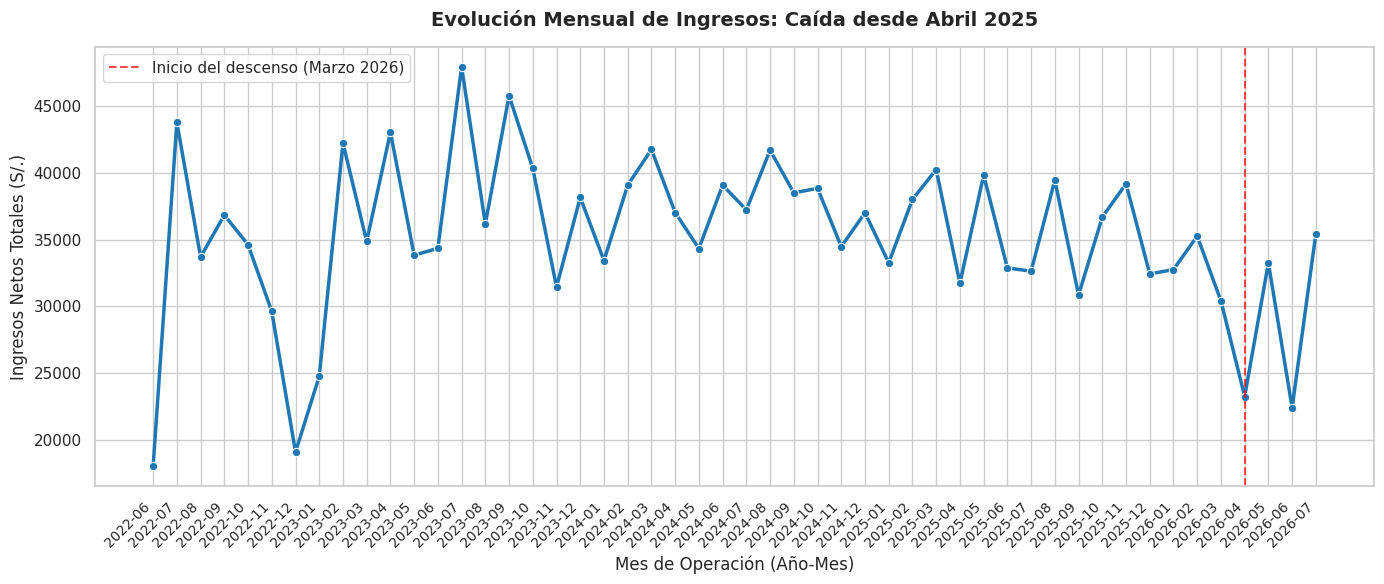

In [27]:
#Graficar la tendencia
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar un tamaño más ancho para dar espacio al eje X
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# 2. Asegurar que las fechas sean texto legible
tendencia_grafico = tendencia_mensual.copy()
tendencia_grafico.index = tendencia_grafico.index.astype(str)

# 3. Dibujar la línea destacando los puntos de cada mes
sns.lineplot(
    x=tendencia_grafico.index,
    y=tendencia_grafico.values,
    marker="o",
    color="#1f77b4", # Un azul profesional
    linewidth=2.5
)

# 4. Rotar las fechas 45 grados para mejor lectura
plt.xticks(rotation=45, ha='right', fontsize=10)

# 5. Agregar titulos
plt.title("Evolución Mensual de Ingresos: Caída desde Abril 2025", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Mes de Operación (Año-Mes)", fontsize=12)
plt.ylabel("Ingresos Netos Totales (S/.)", fontsize=12)

# Añadir una línea vertical punteada justo en Abril 2025 para marcar el hito
if "2025-04" in tendencia_grafico.index:
    plt.axvline(x="2026-04", color="red", linestyle="--", alpha=0.7, label="Inicio del descenso (Marzo 2026)")
    plt.legend()

plt.tight_layout()
plt.show()


#Noches Operadas, ingreso por noche, pedidos y ticket promedio

In [28]:
noches_por_mes = productos.groupby(productos["FechaNegocio"].astype(str).str[:7])["FechaNegocio"].nunique()
noches_por_mes = noches_por_mes.rename("NochesOperadas")
print(noches_por_mes.tail(16))

FechaNegocio
2025-04    12
2025-05    14
2025-06    13
2025-07    13
2025-08    16
2025-09    12
2025-10    13
2025-11    14
2025-12    13
2026-01    12
2026-02    12
2026-03    13
2026-04    10
2026-05    15
2026-06    10
2026-07    14
Name: NochesOperadas, dtype: int64


In [29]:
tendencia_mensual_df = productos.groupby(productos["FechaNegocio"].astype(str).str[:7]).agg(
    IngresoTotal=("IngresoNeto", "sum")
).reset_index().rename(columns={"FechaNegocio": "Mes"})

tendencia_mensual_df = tendencia_mensual_df.merge(
    noches_por_mes.reset_index().rename(columns={"FechaNegocio": "Mes"}), on="Mes"
)

tendencia_mensual_df["IngresoPromedioPorNoche"] = (
    tendencia_mensual_df["IngresoTotal"] / tendencia_mensual_df["NochesOperadas"]
)

print(tendencia_mensual_df.tail(16))

        Mes  IngresoTotal  NochesOperadas  IngresoPromedioPorNoche
34  2025-04       31718.0              12              2643.166667
35  2025-05       39833.0              14              2845.214286
36  2025-06       32873.5              13              2528.730769
37  2025-07       32634.0              13              2510.307692
38  2025-08       39457.0              16              2466.062500
39  2025-09       30853.0              12              2571.083333
40  2025-10       36683.0              13              2821.769231
41  2025-11       39182.0              14              2798.714286
42  2025-12       32427.0              13              2494.384615
43  2026-01       32753.0              12              2729.416667
44  2026-02       35263.0              12              2938.583333
45  2026-03       30403.5              13              2338.730769
46  2026-04       23240.0              10              2324.000000
47  2026-05       33256.0              15              2217.06

In [30]:
pedidos_por_mes = productos.groupby(productos["FechaNegocio"].astype(str).str[:7])["Nro. del Pedido"].nunique()
pedidos_por_mes = pedidos_por_mes.rename("PedidosUnicos")

resumen = tendencia_mensual_df.merge(pedidos_por_mes.reset_index().rename(columns={"FechaNegocio": "Mes"}), on="Mes")
resumen["PedidosPorNoche"] = resumen["PedidosUnicos"] / resumen["NochesOperadas"]
resumen["TicketPromedioMes"] = resumen["IngresoTotal"] / resumen["PedidosUnicos"]

print(resumen[["Mes","IngresoPromedioPorNoche","PedidosPorNoche","TicketPromedioMes"]].tail(16))

        Mes  IngresoPromedioPorNoche  PedidosPorNoche  TicketPromedioMes
34  2025-04              2643.166667        65.833333          40.149367
35  2025-05              2845.214286        69.642857          40.854359
36  2025-06              2528.730769        61.846154          40.887438
37  2025-07              2510.307692        65.153846          38.528926
38  2025-08              2466.062500        63.875000          38.607632
39  2025-09              2571.083333        65.250000          39.403576
40  2025-10              2821.769231        70.307692          40.134573
41  2025-11              2798.714286        69.714286          40.145492
42  2025-12              2494.384615        64.384615          38.741935
43  2026-01              2729.416667        70.083333          38.945303
44  2026-02              2938.583333        67.750000          43.373924
45  2026-03              2338.730769        59.307692          39.433852
46  2026-04              2324.000000        55.6000

#Ingreso Total vs. Ingreso por Noche Operada (Últimos 16 Meses)

/tmp/ipykernel_1548/2218986595.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_grafico["Mes"], rotation=45, ha='right', fontsize=10)


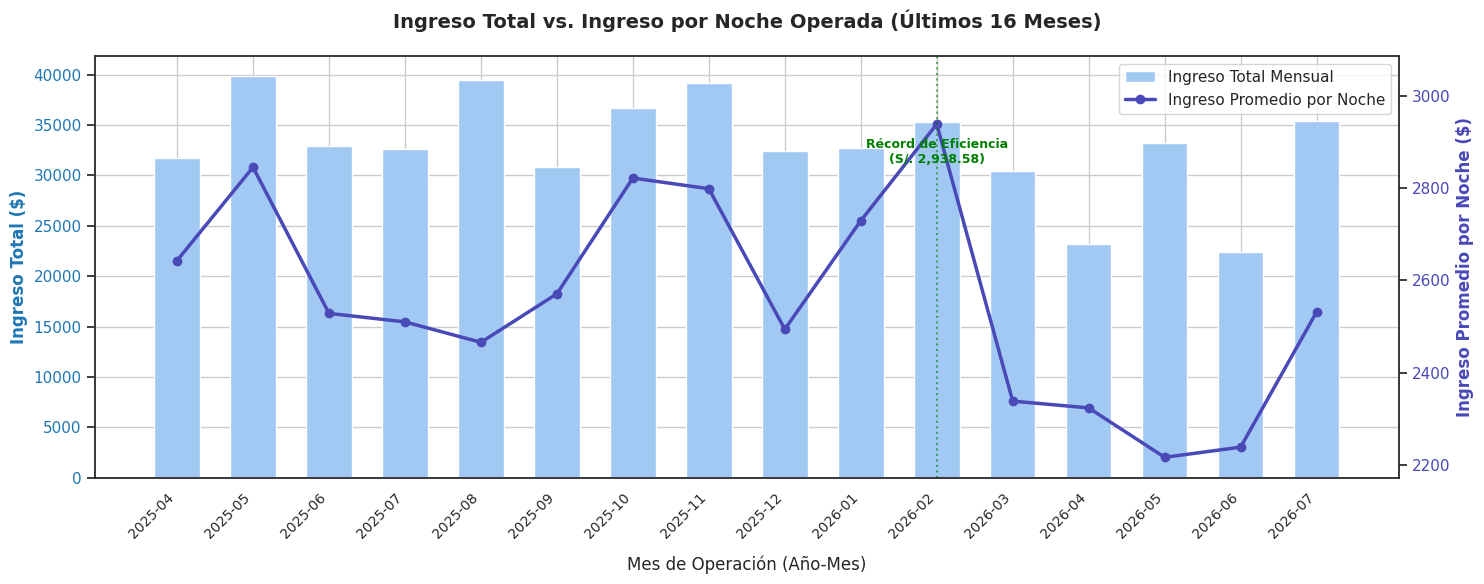

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos los últimos 16 meses
df_grafico = tendencia_mensual_df.tail(16).copy()

# Aseguramos que la columna Mes sea texto limpio para el eje X
df_grafico["Mes"] = df_grafico["Mes"].astype(str)

# 2. Configurar el tamaño del gráfico y estilo base
fig, ax1 = plt.subplots(figsize=(15, 6))
sns.set_theme(style="white")

# 3. EJE 1 (Barras - Izquierdo): Ingreso Total Mensual
color_barras = "#a1c9f4" # Azul suave
ax1.bar(df_grafico["Mes"], df_grafico["IngresoTotal"], color=color_barras, label="Ingreso Total Mensual", width=0.6)
ax1.set_xlabel("Mes de Operación (Año-Mes)", fontsize=12, labelpad=10)
ax1.set_ylabel("Ingreso Total ($)", color="#1f77b4", fontsize=12, fontweight="bold")
ax1.tick_params(axis='y', labelcolor="#1f77b4")
ax1.set_xticklabels(df_grafico["Mes"], rotation=45, ha='right', fontsize=10)

# 4. EJE 2 (Línea - Derecho): Ingreso Promedio por Noche (Se superpone compartiendo el eje X)
ax2 = ax1.twinx()
color_linea = "#4949b7" # Azul
ax2.plot(df_grafico["Mes"], df_grafico["IngresoPromedioPorNoche"], color=color_linea, marker="o", linewidth=2.5, label="Ingreso Promedio por Noche")
ax2.set_ylabel("Ingreso Promedio por Noche ($)", color=color_linea, fontsize=12, fontweight="bold")
ax2.tick_params(axis='y', labelcolor=color_linea)

# 5. Resaltar visualmente Febrero 2026 (Corrección de margen)
if "2026-02" in df_grafico["Mes"].values:
    posicion_feb = list(df_grafico["Mes"]).index("2026-02")
    ax2.axvline(x=posicion_feb, color="green", linestyle=":", alpha=0.6)
    valor_feb = df_grafico.loc[df_grafico["Mes"] == "2026-02", "IngresoPromedioPorNoche"].values[0]

    # AJUSTE CRUCIAL: Le damos un 5% más de espacio al techo del eje derecho para que quepa el texto
    ax2.set_ylim(df_grafico["IngresoPromedioPorNoche"].min() * 0.98, df_grafico["IngresoPromedioPorNoche"].max() * 1.05)

    # Dibujamos el texto un poco más abajo del punto máximo, no arriba
    ax2.text(posicion_feb, valor_feb - 30, "Récord de Eficiencia\n(S/. 2,938.58)",
             color="green", fontsize=9, fontweight="bold", ha="center", va="top")

# 6. Títulos y unificación de etiquetas
plt.title("Ingreso Total vs. Ingreso por Noche Operada (Últimos 16 Meses)", fontsize=14, fontweight='bold', pad=20)
fig.tight_layout()

lineas, etiquetas = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas + lineas2, etiquetas + etiquetas2, loc="upper right")


plt.savefig("img/ingresototal_vs_ingresonocheoperada.png", dpi=150, bbox_inches="tight")
plt.show()


#Pedidos por Noche

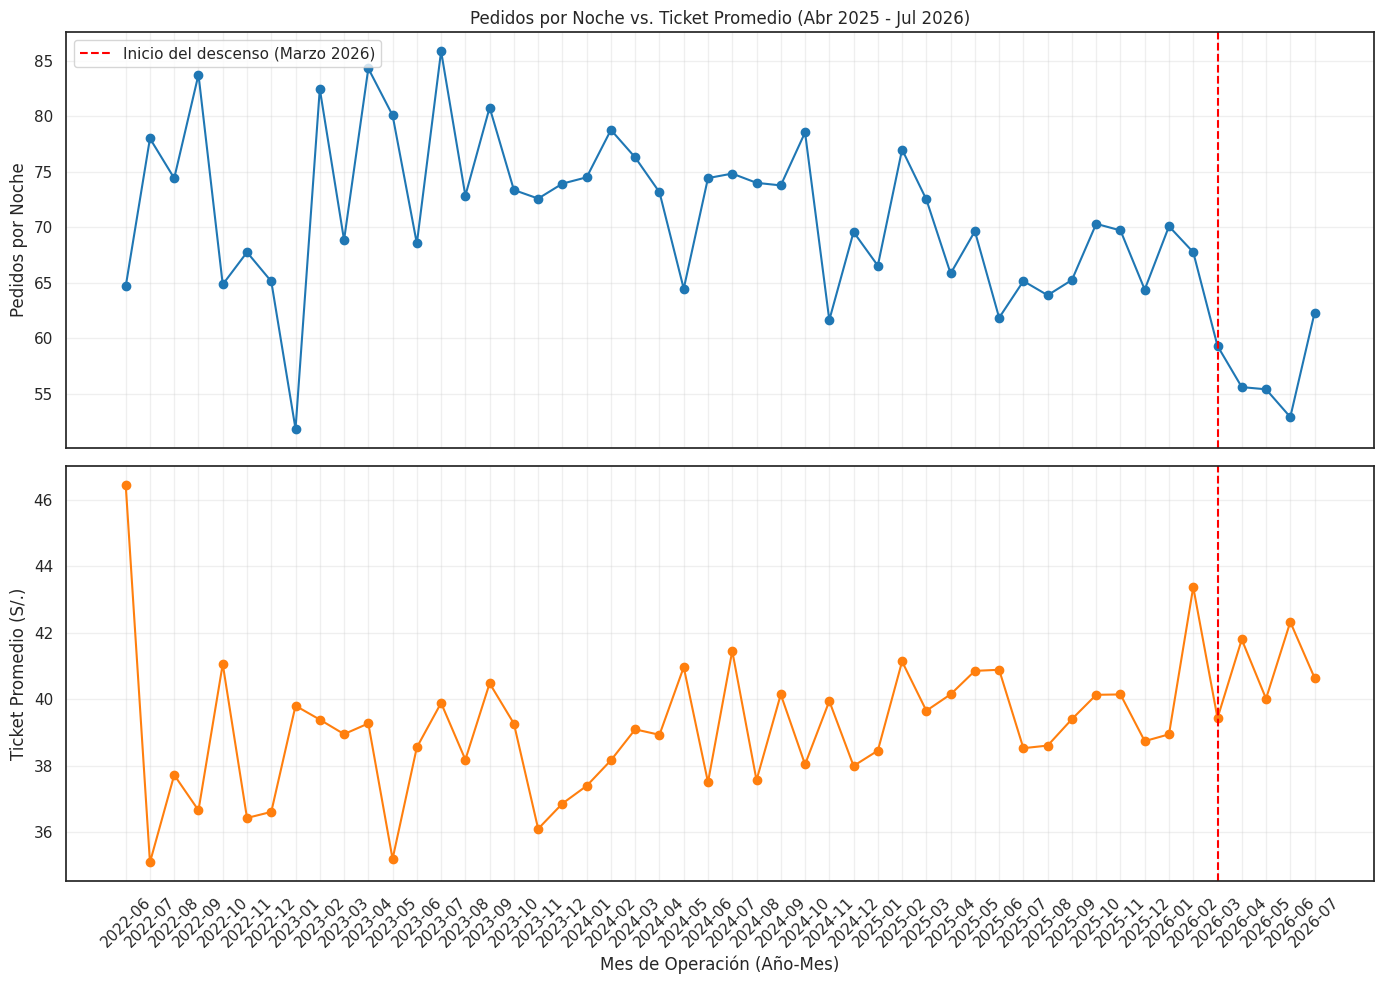

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel 1: Pedidos por noche
axes[0].plot(resumen["Mes"].astype(str), resumen["PedidosPorNoche"], marker="o", color="#1f77b4")
axes[0].axvline(x="2026-03", color="red", linestyle="--", label="Inicio del descenso (Marzo 2026)")
axes[0].set_ylabel("Pedidos por Noche")
axes[0].set_title("Pedidos por Noche vs. Ticket Promedio (Abr 2025 - Jul 2026)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Ticket promedio
axes[1].plot(resumen["Mes"].astype(str), resumen["TicketPromedioMes"], marker="o", color="#ff7f0e")
axes[1].axvline(x="2026-03", color="red", linestyle="--")
axes[1].set_ylabel("Ticket Promedio (S/.)")
axes[1].set_xlabel("Mes de Operación (Año-Mes)")
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("img/pedidos_vs_ticket.png", dpi=150, bbox_inches="tight")
plt.show()

#Desempeño por mesero

In [33]:
# 1. Calculamos el ingreso total y el número de pedidos únicos por mesero
metricas_meseros = productos.groupby("Mesero").agg(
    Ingreso_Total=("IngresoNeto", "sum"),
    Pedidos_Unicos=("Nro. del Pedido", "nunique")
)

# 2. Calculamos el ticket promedio
metricas_meseros["Ticket_Promedio"] = metricas_meseros["Ingreso_Total"] / metricas_meseros["Pedidos_Unicos"]

# 3. Filtramos meseros con muy pocos pedidos (ruido) y ordenamos por el ticket promedio más alto
top_eficiencia = metricas_meseros[metricas_meseros["Pedidos_Unicos"] > 10].sort_values(by="Ticket_Promedio", ascending=False)

print("--- TOP MESEROS POR TICKET PROMEDIO ---")
print(top_eficiencia[["Pedidos_Unicos", "Ticket_Promedio"]].head(10))

--- TOP MESEROS POR TICKET PROMEDIO ---
               Pedidos_Unicos  Ticket_Promedio
Mesero                                        
Mesero_3                   11        56.000000
Mesero_53                  64        55.234375
Mesero_9                   34        52.441176
Mesero_6                   65        48.600000
Sin registrar             745        47.965772
Mesero_72                 223        47.385650
Mesero_59                  45        46.755556
Mesero_71                  62        46.548387
Mesero_46                  49        44.489796
Mesero_4                  177        43.694915


#Top productos por ingreso neto

In [34]:
top_productos = productos.groupby("Nombre del Producto")["IngresoNeto"].sum().sort_values(ascending=False).head(10)
print("--- TOP 5 PRODUCTOS POR INGRESO NETO ---")
print(top_productos)


--- TOP 5 PRODUCTOS POR INGRESO NETO ---
Nombre del Producto
Pilsen                     113730.0
Medellin                    91712.0
Cuzqueña Trigo              83340.0
Cartavio Black              65631.0
Jarra Pomalca Rubio         51660.0
Paz Soldan                  48930.0
Cartavio 5 años             47538.0
Jarra Cartavio Black        45840.0
Jarra Medellin              45311.0
Jarra Cartavio Superior     41332.0
Name: IngresoNeto, dtype: float64


In [35]:
%%writefile README.md
# Análisis de Ventas — Restobar (Fase 1)

## Contexto del proyecto
Análisis de datos transaccionales reales de un restobar (nombre omitido por
confidencialidad del negocio), operando viernes, sábado y domingo desde
2022. Los datos provienen del sistema de punto de venta interno (WePOS
sobre WooCommerce), exportados como historial de pedidos ítem por ítem.

**Nota sobre privacidad:** el dataset original no se incluye en este
repositorio por decisión del negocio. Este README documenta el proceso
completo de limpieza, análisis y hallazgos, con outputs y gráficos
incluidos. Los nombres del personal fueron anonimizados.

## Preguntas de negocio
- ¿Cuáles son los productos más vendidos, en ingreso y en volumen?
- ¿Cómo ha evolucionado el ingreso mes a mes desde 2022?
- ¿La caída de ingresos observada desde marzo 2026 es real o un efecto de
  menos días operados?
- Si es real, ¿viene de menos clientes o de menor gasto por cliente?

## Proceso de limpieza y decisiones clave

**Estructura de los datos:** cada pedido genera una fila "cabecera" con el
nombre del mesero/a (Precio = 0, sin variación de producto) seguida de una
fila por cada producto vendido. Se separaron ambos niveles para no
contaminar el conteo de productos vendidos con los registros de personal.

**Corrección de "fecha de negocio":** el local opera hasta la madrugada
(viernes/domingo hasta 2-3am, sábado hasta 4-5am). Los pedidos hechos antes
de las 6am se reasignaron a la fecha de la noche anterior, para que un
pedido del sábado 1am se cuente como parte de la noche del viernes, tal
como opera el negocio realmente.

**Consolidación de nombres de personal:** variantes como 'NN', 'NN2',
'NNN', 'Nn', 'Mary-Barra' correspondían todas a pedidos hechos en la barra
(confirmado con el negocio) y se unificaron bajo 'Barra'. Los nombres
reales del personal se anonimizaron como Mesero_1, Mesero_2, etc.

**Valores nulos:**
- `Variación del Producto` y `Descuento`: nulos normales (no todos los
  productos tienen variación ni descuento), se rellenaron con "Sin
  variación" y 0 respectivamente.
- `Mesero` (1,023 filas, ~1%): vacíos reales por fallas de registro del
  personal, especialmente al inicio del sistema. Se categorizaron como
  "Sin registrar" en vez de eliminarse o inferirse.
- Una fila totalmente vacía (fila fantasma del export) se eliminó.

## Hallazgos principales

**1. Estacionalidad:** el negocio muestra un patrón estacional consistente
año a año, con picos a mediados de año (jul-oct) y valles a inicio de año
(dic-feb).

**2. Caída de ingresos desde marzo 2026 — confirmada, no es un artefacto
de calendario:** el ingreso promedio por noche operada (ajustado por
número real de noches trabajadas, no solo el total mensual) cayó ~14.5%
entre marzo-junio 2026 frente al promedio de abril 2025-febrero 2026.

Al cruzar los ingresos netos con las noches realmente operadas, se
corrigieron sesgos del análisis mensual tradicional (que solo mira el
total facturado):

- *Pico de eficiencia (febrero 2026):* el mes más eficiente de la serie
  reciente. Con un ingreso total moderado (S/ 35,263) mostró el mayor
  ingreso promedio por noche (S/ 2,938.58) operando solo 12 noches — la
  mejor relación consumo/noche del periodo analizado.
- *Abril y junio 2026 — la caída es real, no solo un efecto de
  calendario:* ambos meses tuvieron menos noches operadas por feriados y
  elecciones (10 noches cada uno, frente a un promedio de ~13). Sin
  embargo, el ingreso promedio por noche (S/ 2,324 en abril, S/ 2,239 en
  junio) también quedó por debajo del promedio histórico (~S/ 2,668),
  indicando que la caída no se explica solo por menos noches trabajadas.
- *Mayo 2026 — más noches, menor rendimiento por noche:* con 15 noches
  operadas (más que el promedio), el ingreso total fue de S/ 33,256, pero
  el ingreso promedio por noche (S/ 2,217.07) fue el más bajo del periodo
  analizado. El dataset no incluye información de costos, por lo que no
  es posible atribuir esto a gastos operativos.

**3. La caída viene de menor afluencia, no de menor gasto por cliente:**
el ticket promedio por pedido se mantuvo estable (~S/ 40) durante todo el
periodo. En cambio, los pedidos por noche cayeron ~16% en el mismo corte
(de ~66.7 a ~55.8 pedidos/noche). Julio 2026 muestra recuperación parcial
hacia los niveles históricos.

**4. Factores de contexto identificados junto con el negocio:** parte de
la caída coincide con días no operados por feriados/elecciones (Viernes
Santo el 5 de abril, primera vuelta electoral 11-12 de abril, segunda
vuelta 6-7 de junio de 2026 — no laborales por disposición legal). Sin
embargo, el ajuste por noche operada confirma que la caída persiste más
allá de estos días puntuales. El negocio también reportó una reducción en
su inversión de publicidad en redes sociales desde inicios de 2026,
coincidiendo con el periodo de menor afluencia. Meses con publicidad
reforzada (febrero y julio 2026) muestran los mejores desempeños del
periodo reciente. Sin datos de inversión y alcance de campañas, esto se
presenta como hipótesis cualitativa, no como relación causal comprobada —
ver "Próximos pasos".

**5. Top 5 productos por ingreso neto:**

| Producto | Ingreso Neto (S/.) |
|---|---|
| Pilsen | 113,730 |
| Medellín | 91,712 |
| Cuzqueña Trigo | 83,340 |
| Cartavio Black | 65,631 |
| Jarra Pomalca Rubio | 51,660 |

**6. Desempeño por mesero (top 10 por ticket promedio, mín. 10 pedidos):**

| Mesero | Pedidos Únicos | Ticket Promedio (S/.) |
|---|---|---|
| Mesero_1 | 11 | 56.00 |
| Mesero_2 | 64 | 55.23 |
| Mesero_3 | 34 | 52.44 |
| Mesero_4 | 65 | 48.60 |
| Sin registrar | 745 | 47.97 |
| Mesero_5 | 223 | 47.39 |
| Mesero_6 | 45 | 46.76 |
| Mesero_7 | 62 | 46.55 |
| Mesero_8 | 49 | 44.49 |
| Mesero_9 | 177 | 43.69 |

**7. Pedidos sin registrar:** los 745 pedidos categorizados como "Sin
registrar" arrojaron un ticket promedio de S/ 47.96, dentro del rango de
ticket promedio observado en el resto del personal (S/ 43.69-56.00). Esto
sugiere que estos pedidos huérfanos no corresponden a un patrón de consumo
atípico y no distorsionan las métricas generales. El negocio ya tenía
conocimiento de que el personal a veces omitía registrar su nombre en el
sistema, pero al dimensionar la magnitud del problema (745 pedidos),
decidió implementar una política más estricta de registro obligatorio —
un ejemplo concreto de cómo este análisis generó una acción operativa
real.

## Limitaciones del dataset
- No hay identificador de cliente, por lo que no es posible analizar
  clientes recurrentes ni frecuencia de visita individual.
- La relación entre publicidad y ventas es una correlación temporal
  observada, no una relación causal comprobada con datos de marketing.
- El ticket promedio por mesero puede reflejar el tipo de mesa/turno
  asignado, no necesariamente habilidad individual de venta.
- El dataset no incluye información de costos operativos, por lo que no
  es posible relacionar ingresos con rentabilidad real.

## Impacto
Este análisis generó tres acciones concretas en el negocio:

- **Registro de personal:** al dimensionar que 745 pedidos (~0.8% del
  total) carecían de mesero registrado por fallas de captura, el negocio
  implementó una política de registro obligatorio en el sistema POS.
- **Estrategia de productos:** al identificar los productos más vendidos
  por ingreso, se recomendó explorar combos que integren estos productos
  de alta rotación junto con productos de comida o de menor venta, como
  estrategia para impulsar el consumo cruzado.
- **Revisión de percepción sobre el desempeño del personal:** el dueño
  percibía a un par de meseros como los más destacados del equipo; los
  datos mostraron que, si bien su ticket promedio por pedido era alto, su
  volumen de pedidos atendidos era menor que el del resto del personal —
  evidenciando que la percepción y el desempeño medido en datos no
  siempre coinciden.

## Próximos pasos (Fase 2)
Cruzar el gasto y alcance mensual de campañas de Meta Ads con
`PedidosPorNoche`, incluyendo una versión con un mes de rezago, para
evaluar si la correlación observada se sostiene con datos de marketing
reales.

## Herramientas
Python (pandas, matplotlib, seaborn), Google Colab.

Overwriting README.md
